In [7]:
%run ../Lanes.ipynb

Test 1: Empty Road
  Expected flow = 0, Actual flow = 1.55
  Expected jam fraction = 0, Actual jam fraction = 0.0
  FAIL

Test 2: Full Road
  Expected jam fraction = 1, Actual jam fraction = 1.000
  PASS
Totoal Average Flow: 0.45544554455445546
Total Jamming Fraction: 0.13336517793746844
[[ 5]
 [-1]
 [ 2]
 [-1]
 [-1]
 [-1]
 [ 3]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [ 0]
 [-1]
 [ 1]
 [ 0]
 [-1]
 [ 1]
 [-1]
 [ 1]
 [-1]
 [ 1]
 [ 0]
 [-1]
 [ 1]
 [ 0]
 [-1]
 [ 1]
 [-1]
 [-1]
 [ 2]
 [ 0]
 [-1]
 [ 1]
 [-1]
 [-1]
 [ 2]
 [ 0]
 [-1]
 [ 1]
 [-1]
 [-1]
 [ 2]
 [ 0]
 [-1]
 [ 1]
 [-1]
 [-1]
 [ 2]
 [ 0]
 [-1]
 [ 1]
 [-1]
 [-1]
 [ 2]
 [ 0]
 [-1]
 [ 1]
 [-1]
 [-1]
 [ 2]
 [ 0]
 [-1]
 [ 1]
 [-1]
 [-1]
 [ 2]
 [ 0]
 [-1]
 [ 1]
 [-1]
 [-1]
 [ 2]
 [ 0]
 [-1]
 [ 

# Visualization

In [ ]:
model = Multi_Lane_Traffic(cells=20, lanes=6, density=0.2, vmax=5, p=0.2, random_state=42)
model.simulate(100)

array([[-1,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0, -1, -1,  0,  0,  0,
        -1, -1, -1, -1],
       [-1, -1, -1, -1, -1, -1, -1,  0,  0,  0,  0, -1, -1, -1, -1, -1,
        -1, -1, -1, -1],
       [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  0,  0,  0,  0,  0,
        -1, -1, -1, -1],
       [-1, -1, -1,  0,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1,  0,  0,
        -1, -1, -1, -1],
       [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  0,  0,  0,  0,  0, -1,
        -1, -1, -1, -1],
       [-1,  0,  0,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1]])

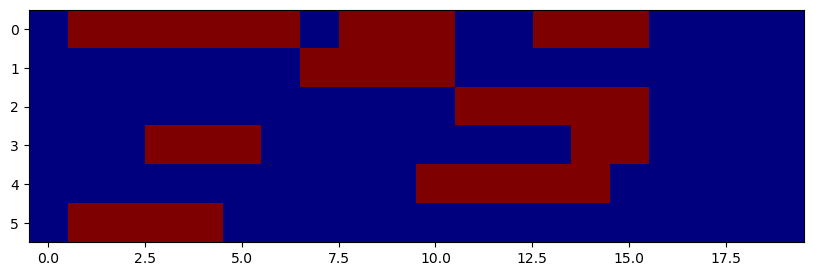

In [11]:
t = model.history[81]
plt.figure(figsize=(10, 6))
plt.imshow(t, cmap='jet')


In [6]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap, BoundaryNorm
from IPython.display import HTML
import numpy as np

# --- SAFETY CHECK ---
if not hasattr(model, 'history') or len(model.history) == 0:
    print("Error: Model has no history. Did you run model.simulate()?")
else:
    fig, ax = plt.subplots(figsize=(10, 5))

    # --- CUSTOM COLORS ---
    # Index 0 is for -1 (Empty Road)
    # Index 1 is for 0 (Stopped), Index 2 is for 1 (Slow), etc.
    colors = [
        '#333333',  # -1: Empty Road (Dark Grey)
        '#FF0000',  #  0: Red (Stopped)
        '#FF8C00',  #  1: Dark Orange
        '#FFD700',  #  2: Gold/Yellow
        '#ADFF2F',  #  3: Light Green
        '#00BFFF',  #  4: Deep Sky Blue
        '#0000FF'   #  5: Pure Blue (Max Speed)
    ]

    cmap = ListedColormap(colors)
    
    # Bounds: -1 maps to colors[0], 0 maps to colors[1], etc.
    bounds = [-1.5, -0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
    norm = BoundaryNorm(bounds, cmap.N)

    def update(frame_idx):
        ax.clear()
        
        # 1. RETRIEVE DATA
        try:
            vel_grid = np.array(model.history[frame_idx])
        except IndexError:
            return
            
        # 2. DRAW GRID
        ax.imshow(vel_grid, cmap=cmap, norm=norm, aspect='auto')
        
        # 3. OVERLAY NUMBERS
        rows, cols = np.where(vel_grid != -1)
        for l, c in zip(rows, cols):
            val = vel_grid[l][c]
            if l < model.lanes and c < model.cells:
                # Use white text for visibility against dark/colored backgrounds
                ax.text(c, l, str(val), ha='center', va='center', 
                        color='white', fontweight='bold', fontsize=8)

        # 4. FORMATTING
        ax.set_xticks(np.arange(-0.5, model.cells, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, model.lanes, 1), minor=True)
        ax.grid(which='minor', color='white', linestyle='-', linewidth=0.5)
        ax.tick_params(which='minor', bottom=False, left=False)
        ax.set_title(f"Step {frame_idx} (Red=Slow, Blue=Fast)")

    # Create Animation
    ani = animation.FuncAnimation(fig, update, frames=len(model.history), interval=200)
    plt.close()
    
    # Render
    display(HTML(ani.to_jshtml()))

## Simple Test

## Multiple Cars in the larger grids